+ Mục tiêu của EDA là hiểu dữ liệu để biết:
    + Dữ liệu có bao nhiêu mẫu (samples) và bao nhiêu đặc trưng (features).
    + Kiểu dữ liệu của từng cột (int, float, object, datetime...).
    + Có dữ liệu bị thiếu (Missing Values) hay không.
    + Có dữ liệu trùng lặp (Duplicates) hay không.
    + Phân bố của từng biến như thế nào.
    + Có ngoại lệ (Outliers) hay không.
    + Các đặc trưng có tương quan với nhau ra sao.
    + Đặc trưng nào có ảnh hưởng đến biến mục tiêu (Target).
+ Thống kê mô tả: df.describe()
+ Kiểm tra cấu trúc dữ liệu: df.info()
                           df.shape
                           df.columns
                           df.dtypes
+ Missing value: df.isnull().sum()
+ Phân bố dữ liệu
+ Outliers
+ Mối quan hệ giữa các feature
+ Correlation: df.corr()
+ Phân bố của target: df["Outcome"].value_counts()

Import library

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix

Read dataset_cleaning

In [3]:
data = pd.read_csv(r'D:\AI_Projects\Project_1\data\processed\diabetes_clean.csv', sep =';')
data.head()
data.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
2424,3,126,88,41,235,39.3,0.704,27,0
2425,4,123,62,0,0,32.0,0.226,35,1
2426,1,80,74,11,60,30.0,0.527,22,0
2427,1,96,64,27,87,33.2,0.289,21,0
2428,6,105,70,32,68,30.8,0.122,37,0


Statistics

In [11]:
data.info()
data.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2429 entries, 0 to 2428
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               2429 non-null   int64  
 1   Glucose                   2429 non-null   int64  
 2   BloodPressure             2429 non-null   int64  
 3   SkinThickness             2429 non-null   int64  
 4   Insulin                   2429 non-null   int64  
 5   BMI                       2429 non-null   float64
 6   DiabetesPedigreeFunction  2429 non-null   float64
 7   Age                       2429 non-null   int64  
 8   Outcome                   2429 non-null   int64  
dtypes: float64(2), int64(7)
memory usage: 170.9 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,2429.000000,2429.000000,2429.000000,2429.000000,2429.000000,2429.000000,2429.000000,2429.000000,2429.000000
mean,3.823384,121.842734,69.298065,20.717579,80.922602,32.398724,0.490748,32.867435,0.392343
std,3.296148,31.849031,18.307057,15.688434,117.223704,6.958756,0.360058,11.213506,0.488373
min,0.000000,0.000000,0.000000,0.000000,0.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,100.000000,64.000000,0.000000,0.000000,27.300000,0.252000,24.000000,0.000000
50%,3.000000,117.000000,70.000000,23.000000,38.000000,32.300000,0.382000,29.000000,0.000000
75%,6.000000,142.000000,80.000000,33.000000,130.000000,36.600000,0.652000,39.000000,1.000000
max,17.000000,197.000000,122.000000,63.000000,846.000000,67.100000,2.420000,81.000000,1.000000


+ Missing values
    + Nếu có dữ liệu thiếu:
        + Drop
        + Fill Mean
        + Fill Median
        + Fill Mode

In [5]:
data.isnull().sum()
(data.isnull().sum()/len(data))*100

Pregnancies                 0.0
Glucose                     0.0
BloodPressure               0.0
SkinThickness               0.0
Insulin                     0.0
BMI                         0.0
DiabetesPedigreeFunction    0.0
Age                         0.0
Outcome                     0.0
dtype: float64

Distribution: Phân bố dữ liệu

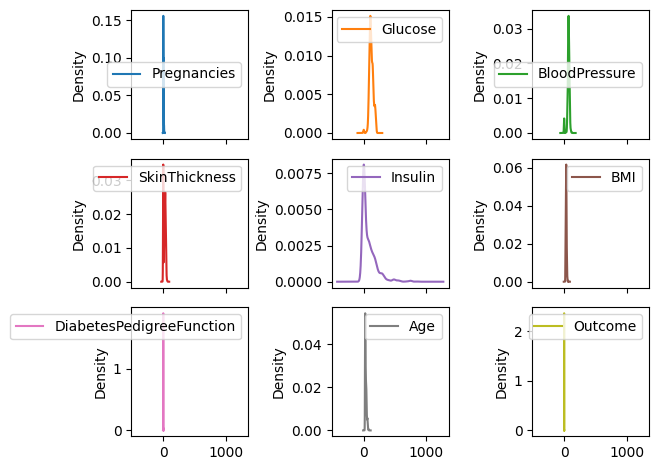

In [6]:
data["Outcome"].value_counts()
data.plot(kind="density", subplots=True, layout=(3,3))
plt.tight_layout()
plt.show()

Phát hiện outliers

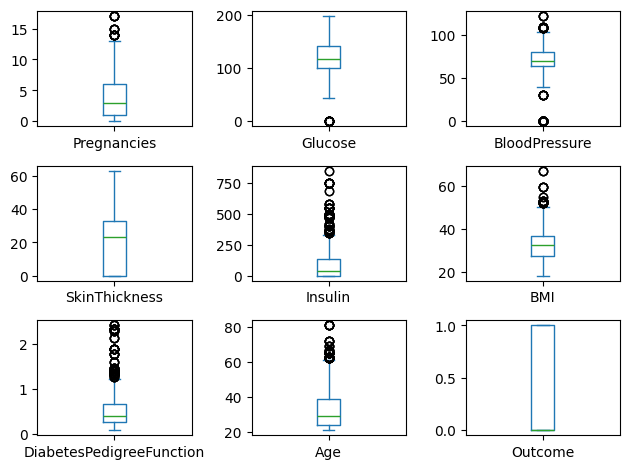

In [13]:
data.plot(kind="box", subplots=True, layout=(3,3))
plt.tight_layout()
plt.show()

+ Correlation: Xem các feature liên quan với nhau như thế nào.
+ Quan sát
    + Correlation > 0.8
    + Correlation < -0.8
    + Multicollinearity

+ Cách đánh giá hệ số tương quan
| |r| | Mức độ             |
|----:|----------------    |
| 0.00 – 0.19 | Rất yếu    |
| 0.20 – 0.39 | Yếu        |
| 0.40 – 0.59 | Trung bình |
| 0.60 – 0.79 | Mạnh       |
| 0.80 – 1.00 | Rất mạnh   |

<Axes: >

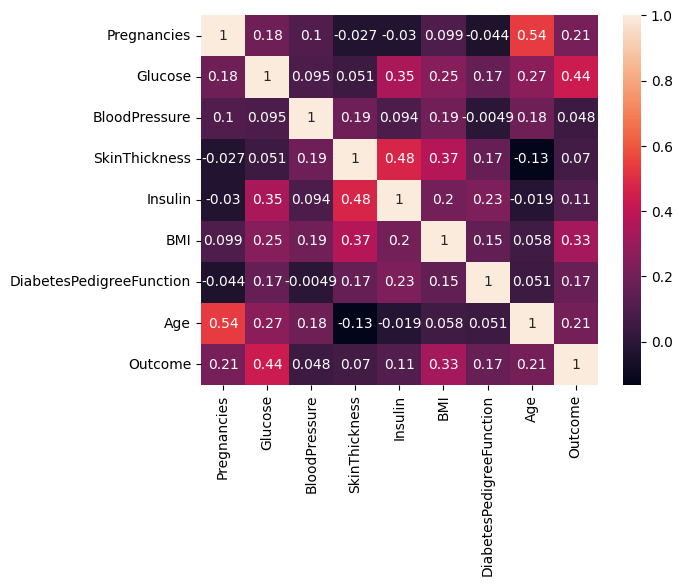

In [14]:
corr = data.corr(numeric_only=True)
plt.tight_layout()
sns.heatmap(corr, annot=True)

Feature Relationships: Xem mối quan hệ giữa các feature.

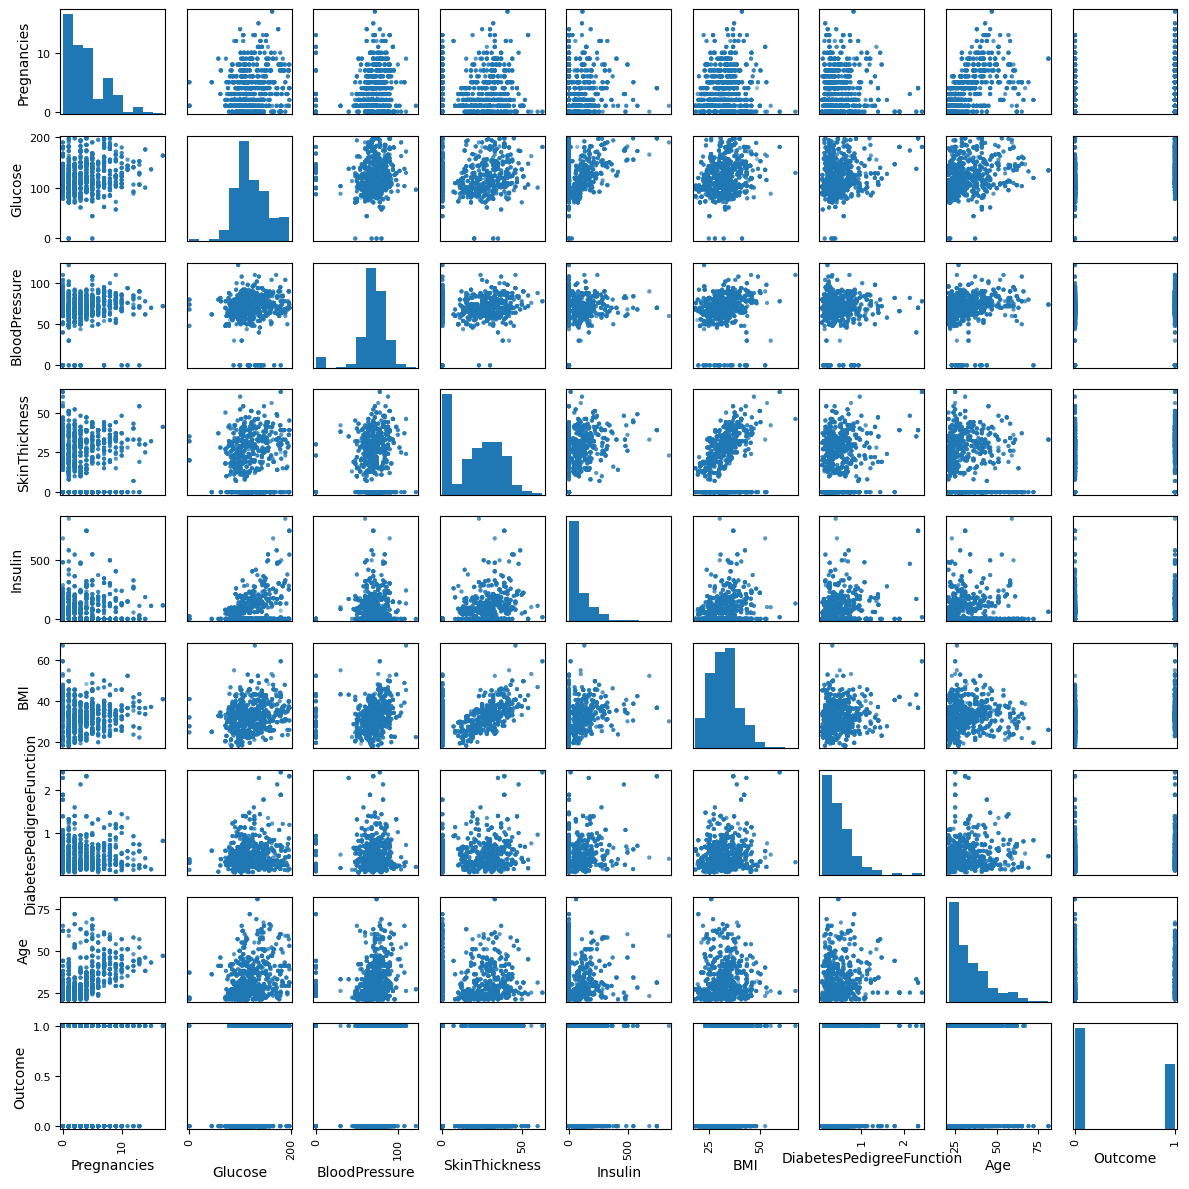

In [15]:
scatter_matrix(data, figsize=(12,12))
plt.tight_layout()
plt.show()

Target Analysis

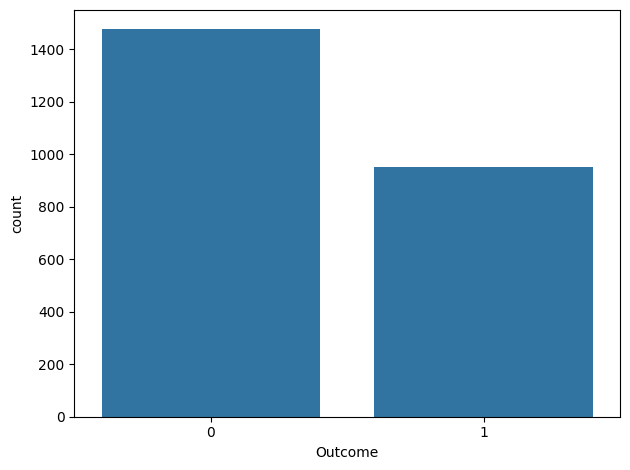

In [16]:
data["Outcome"].value_counts()
sns.countplot(x="Outcome", data=data)
plt.tight_layout()
plt.show()